In [6]:
import os
import pandas as pd
import shutil
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
from sklearn.model_selection import train_test_split
import yaml
import random

In [7]:
IMAGE_DIR = "/mnt/d/Computer-Vision/Projects/Project2/dataset/images"
LABELS_CSV = "/mnt/d/Computer-Vision/Projects/Project2/dataset/labels.csv"

We have to ghange the x , y min and max to x center and width and hight. Yolo wants this format to drawing the BBox.

and change the labels to label Id.

In [8]:
full_df = pd.read_csv(LABELS_CSV)
full_df

,xmin,ymin,xmax,ymax,Frame,Label,Preview URL
0,785,533,905,644,1479498371963069978.jpg,Car,http://crowdai.com/images/Wwj-gorOCisE7uxA/vis...
1,89,551,291,680,1479498371963069978.jpg,Car,http://crowdai.com/images/Wwj-gorOCisE7uxA/vis...
2,268,546,383,650,1479498371963069978.jpg,Car,http://crowdai.com/images/Wwj-gorOCisE7uxA/vis...
3,455,522,548,615,1479498371963069978.jpg,Truck,http://crowdai.com/images/Wwj-gorOCisE7uxA/vis...
4,548,522,625,605,1479498371963069978.jpg,Truck,http://crowdai.com/images/Wwj-gorOCisE7uxA/vis...
...,...,...,...,...,...,...,...
72059,958,559,1045,621,1479506176491553178.jpg,Car,http://crowdai.com/images/UpG-UBLnJWQkavSp/vis...
72060,1038,558,1122,630,1479506176491553178.jpg,Car,http://crowdai.com/images/UpG-UBLnJWQkavSp/vis...
72061,667,558,747,626,1479506176491553178.jpg,Car,http://crowdai.com/images/UpG-UBLnJWQkavSp/vis...
72062,730,568,818,613,1479506176491553178.jpg,Car,http://crowdai.com/images/UpG-UBLnJWQkavSp/vis...


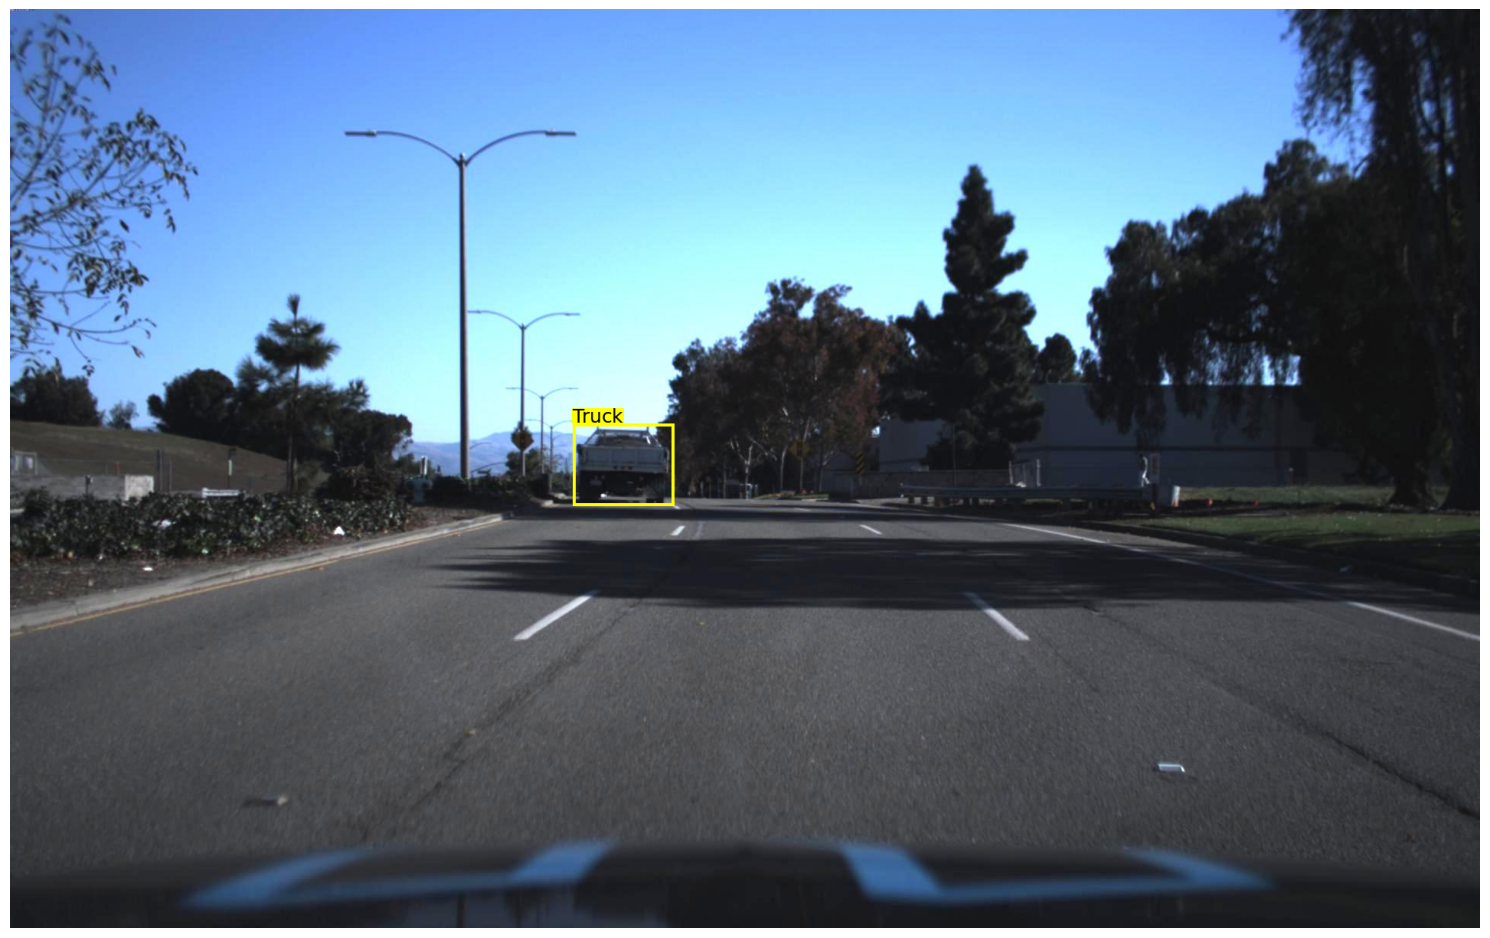

In [9]:
image_name = random.choice(full_df['Frame'].unique())
# Adding the image name to image dir for have full direction of each image.
image_path = os.path.join(IMAGE_DIR, image_name)
# Find all annotations of evey BBox for each image.
image_annotations = full_df[full_df['Frame'] == image_name]

img = Image.open(image_path)
img_drawable = img.copy()

draw = ImageDraw.Draw(img_drawable)

for _, row in image_annotations.iterrows():
    xmin = row['xmin']
    ymin = row['ymin']
    xmax = row['xmax']
    ymax = row['ymax']
    label = row['Label']
    
    color_map = {'Car': 'cyan', 'Truck': 'yellow', 'Pedestrian': 'lime'}
    color = color_map.get(label, 'red')

    draw.rectangle(
        [(xmin, ymin), (xmax, ymax)], 
        outline=color, 
        width=4
    )
    
    font = ImageFont.truetype("DejaVuSans.ttf", size=25)

    text_bbox = draw.textbbox((xmin, ymin - 25), label,font=font)
    draw.rectangle(text_bbox, fill=color)
    draw.text((xmin, ymin - 25), label, fill="black",font=font)

plt.figure(figsize=(15, 10))
plt.imshow(img_drawable)
plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
OUTPUT_DIR = './yolo_dataset/'
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [11]:
class_names = ['car', 'truck', 'pedestrian']
class_map = {name: i for i, name in enumerate(class_names)}

In [12]:
class_map

{'car': 0, 'truck': 1, 'pedestrian': 2}

Making a new column Class id thats working with labels. car=0 truck 1 and pedestrian 2.

In [13]:
full_df['class_id'] = full_df['Label'].str.lower().map(class_map)
# Removing the empty Frame (frames those images are empty) and Label (lable column is empty) rows complitely.
full_df.dropna(subset=['class_id', 'Frame'], inplace=True)
full_df['class_id'] = full_df['class_id'].astype(int)

In [14]:
full_df

,xmin,ymin,xmax,ymax,Frame,Label,Preview URL,class_id
0,785,533,905,644,1479498371963069978.jpg,Car,http://crowdai.com/images/Wwj-gorOCisE7uxA/vis...,0
1,89,551,291,680,1479498371963069978.jpg,Car,http://crowdai.com/images/Wwj-gorOCisE7uxA/vis...,0
2,268,546,383,650,1479498371963069978.jpg,Car,http://crowdai.com/images/Wwj-gorOCisE7uxA/vis...,0
3,455,522,548,615,1479498371963069978.jpg,Truck,http://crowdai.com/images/Wwj-gorOCisE7uxA/vis...,1
4,548,522,625,605,1479498371963069978.jpg,Truck,http://crowdai.com/images/Wwj-gorOCisE7uxA/vis...,1
...,...,...,...,...,...,...,...,...
72059,958,559,1045,621,1479506176491553178.jpg,Car,http://crowdai.com/images/UpG-UBLnJWQkavSp/vis...,0
72060,1038,558,1122,630,1479506176491553178.jpg,Car,http://crowdai.com/images/UpG-UBLnJWQkavSp/vis...,0
72061,667,558,747,626,1479506176491553178.jpg,Car,http://crowdai.com/images/UpG-UBLnJWQkavSp/vis...,0
72062,730,568,818,613,1479506176491553178.jpg,Car,http://crowdai.com/images/UpG-UBLnJWQkavSp/vis...,0


In [15]:
all_image_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

In [16]:
train_files, val_files = train_test_split(all_image_files, test_size=0.1, random_state=42)

In [17]:
def process_data(image_files, all_labels_df, split_name='train'):
  
    output_img_dir = os.path.join(OUTPUT_DIR, 'images', split_name)
    output_label_dir = os.path.join(OUTPUT_DIR, 'labels', split_name)
    os.makedirs(output_img_dir, exist_ok=True)
    os.makedirs(output_label_dir, exist_ok=True)

    for image_name in tqdm(image_files, desc=f"Converting {split_name} data"):
        
        source_image_path = os.path.join(IMAGE_DIR, image_name)
        shutil.copy(source_image_path, output_img_dir)

        label_filename = os.path.splitext(image_name)[0] + '.txt'
        output_label_path = os.path.join(output_label_dir, label_filename)

        group = all_labels_df[all_labels_df['Frame'] == image_name]

        if group.empty:
            open(output_label_path, 'w').close()
            continue

        with Image.open(source_image_path) as img:
            img_width, img_height = img.size

        with open(output_label_path, 'w') as f:
            for _, row in group.iterrows():
                yolo_class_id = row['class_id']
                xmin, xmax, ymin, ymax = row['xmin'], row['xmax'], row['ymin'], row['ymax']

                x_center = ((xmin + xmax) / 2.0) / img_width
                y_center = ((ymin + ymax) / 2.0) / img_height
                
                width = (xmax - xmin) / img_width
                height = (ymax - ymin) / img_height

                f.write(f"{yolo_class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

In [18]:
process_data(train_files, full_df, 'train')

Converting train data: 100%|██████████| 8478/8478 [09:06<00:00, 15.51it/s]


In [19]:
process_data(val_files, full_df, 'val')

Converting val data: 100%|██████████| 942/942 [00:58<00:00, 16.18it/s]


In [20]:
yaml_data = {
    'path': OUTPUT_DIR,
    'train': 'images/train',
    'val': 'images/val',
    'nc': len(class_names),
    'names': class_names
}
with open(os.path.join(OUTPUT_DIR, 'data.yaml'), 'w') as f:
    yaml.dump(yaml_data, f, sort_keys=False)